In [1]:
"""
WMCR Leaching Model - Model Definitions and Setup
"""
from dataclasses import dataclass
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pandas as pd
import os
import json


@dataclass
class WMCRInputs:
    Q_avg_mL_min: float
    T_end_days: float
    Vw_mL: float
    m_s_g: float
    rho_s_g_cm3: float
    M_inf_ng: float
    exp_tag: str = ""


@dataclass
class WMCRParams:
    Ksw: float
    kA_mL_day: float


def solve_wmcr(inputs: WMCRInputs, params: WMCRParams, n_eval: int = 2001):
    """Solve WMCR leaching model"""
    # Derived quantities
    Q_day = inputs.Q_avg_mL_min * 1440.0  # mL/day
    Vs_mL = inputs.m_s_g / inputs.rho_s_g_cm3
    
    # Initial conditions
    Cw0 = 0.0
    Cs0 = inputs.M_inf_ng / Vs_mL if Vs_mL > 0 else 0.0
    Mout0 = 0.0
    
    def rhs(t, y):
        Cw, Cs, Mout = y
        drive = (Cs / params.Ksw) - Cw
        dCw = -(Q_day / inputs.Vw_mL) * Cw + (params.kA_mL_day / inputs.Vw_mL) * drive
        dCs = -(params.kA_mL_day / Vs_mL) * drive
        dMout = Q_day * Cw
        return [dCw, dCs, dMout]
    
    t_eval = np.linspace(0.0, inputs.T_end_days, n_eval)
    y0 = [Cw0, Cs0, Mout0]
    
    sol = solve_ivp(
        rhs,
        t_span=(0.0, inputs.T_end_days),
        y0=y0,
        t_eval=t_eval,
        method="BDF",
        rtol=1e-8,
        atol=1e-10,
    )
    
    if not sol.success:
        raise RuntimeError(f"ODE solve failed: {sol.message}")
    
    return {
        "t_days": sol.t,
        "Cout_ng_mL": sol.y[0],
        "Mout_ng": sol.y[2],
    }


# Set up directories
data_dir = "./data"
output_dir = "./output"

print("Model definitions loaded successfully!")
print(f"Data directory: {data_dir}")
print(f"Output directory: {output_dir}")

Model definitions loaded successfully!
Data directory: ./data
Output directory: ./output


Loading all 9 conditions...
Processing PPDQ_4C_S...
Processing PPDQ_4C_M...
Processing PPDQ_4C_L...
Processing PPDQ_20C_S...
Processing PPDQ_20C_M...
Processing PPDQ_20C_L...
Processing PPDQ_40C_S...
Processing PPDQ_40C_M...
Processing PPDQ_40C_L...

All conditions loaded successfully!

Creating 3x3 panel plot...
Figure saved as: ./output\Figure_4.png


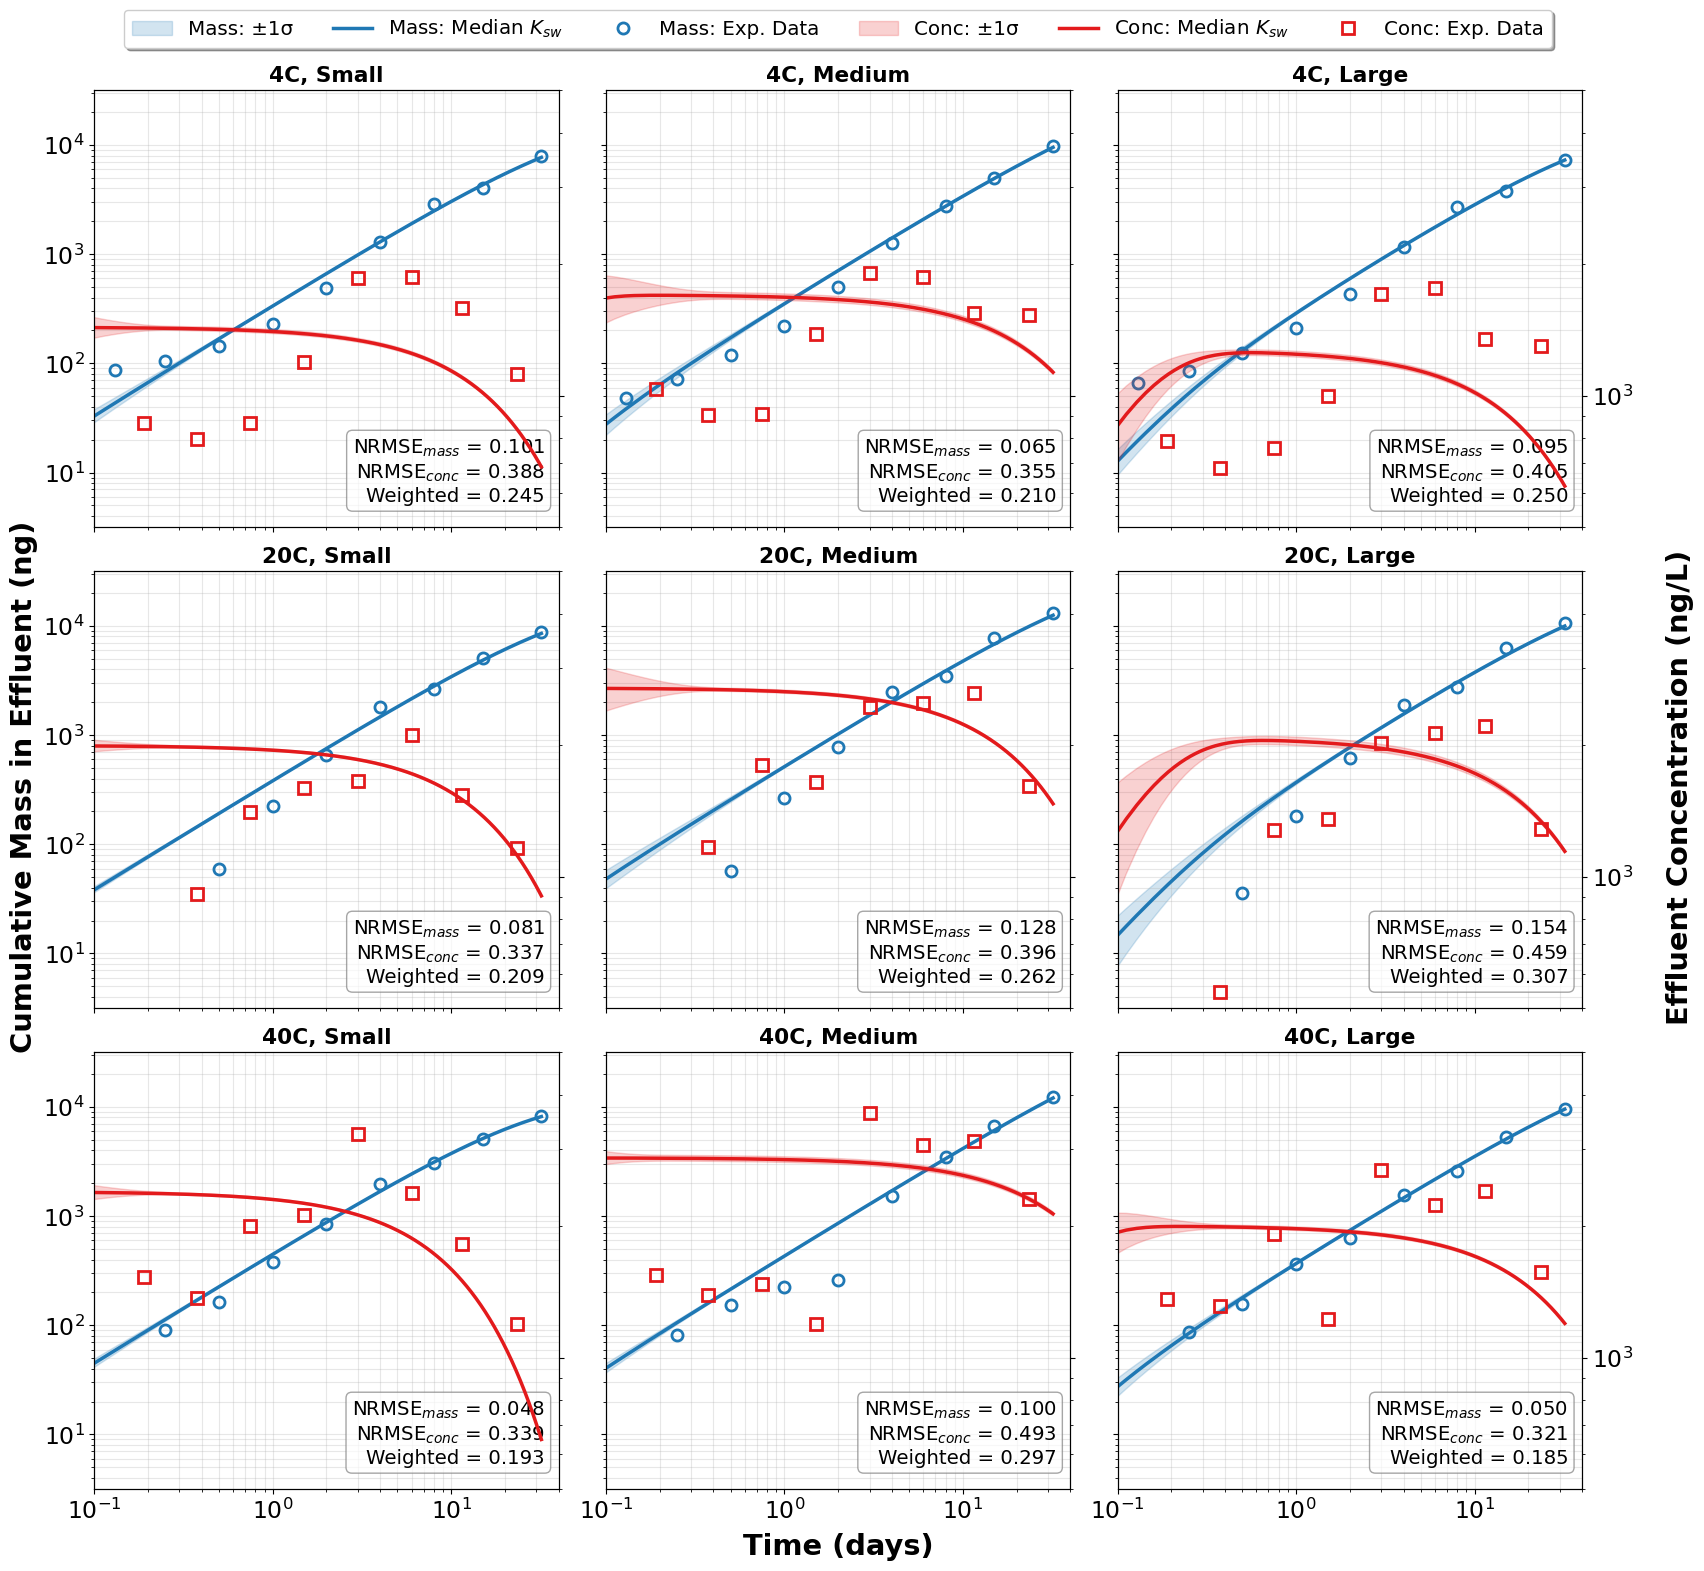


3x3 panel plot complete!


In [2]:
"""
Create comprehensive 3x3 plot showing all conditions with dual axes (Mass and Concentration)
Matching the style from n_figure_2.ipynb but with dual y-axes content
"""

# Define all conditions
temperatures = ['4C', '20C', '40C']
sizes = ['S', 'M', 'L']  # Changed order: Small to Large
size_labels = {'L': 'Large', 'M': 'Medium', 'S': 'Small'}

# Colors matching n_figure_2.ipynb style
color_mass = (31/255, 120/255, 180/255)    # Blue
color_conc = (227/255, 26/255, 28/255)     # Red

# Load and process all conditions
print("Loading all 9 conditions...")
all_results = {}

for temp in temperatures:
    for size in sizes:
        spec_tag_curr = f"PPDQ_{temp}_{size}"
        data_tag_curr = f"PPDQ_{temp}_{size}"
        print(f"Processing {spec_tag_curr}...")
        
        # Load optimization specs
        spec_file_curr = os.path.join(output_dir, f"optimization_specs_{spec_tag_curr}.json")
        with open(spec_file_curr, 'r') as f:
            specs_curr = json.load(f)
        
        # Create inputs from specs
        exp_cond_curr = specs_curr['experiment_conditions']
        inputs_curr = WMCRInputs(
            Q_avg_mL_min=exp_cond_curr['Q_avg_mL_min'],
            T_end_days=exp_cond_curr['T_end_days'],
            Vw_mL=exp_cond_curr['Vw_mL'],
            m_s_g=exp_cond_curr['m_s_g'],
            rho_s_g_cm3=exp_cond_curr['rho_s_g_cm3'],
            M_inf_ng=exp_cond_curr['M_inf_ng'],
            exp_tag=data_tag_curr
        )
        
        # Solve WMCR for all clusters to compute uncertainty
        all_clusters_curr = specs_curr['all_clusters']
        N_clusters_curr = len(all_clusters_curr)
        
        # Find the cluster with the median Ksw value as the representative line
        ksw_values = [c['Ksw'] for c in all_clusters_curr]
        median_idx_curr = int(np.argsort(ksw_values)[N_clusters_curr // 2])
        median_cluster_curr = all_clusters_curr[median_idx_curr]
        params_curr = WMCRParams(
            Ksw=median_cluster_curr['Ksw'],
            kA_mL_day=median_cluster_curr['kA']
        )
        
        # Solve WMCR with median-Ksw parameters (representative line)
        out_curr = solve_wmcr(inputs_curr, params_curr)
        
        cluster_outputs_curr = []
        for cluster in all_clusters_curr:
            cluster_params = WMCRParams(
                Ksw=cluster['Ksw'],
                kA_mL_day=cluster['kA']
            )
            cluster_out = solve_wmcr(inputs_curr, cluster_params)
            cluster_outputs_curr.append(cluster_out)
        
        # Calculate uncertainty from all clusters
        t_curr = out_curr["t_days"]
        n_time_curr = len(t_curr)
        
        # Collect all WMCR predictions at the same time points
        all_mass_curr = np.zeros((N_clusters_curr, n_time_curr))
        all_conc_curr = np.zeros((N_clusters_curr, n_time_curr))
        
        for i, cluster_out in enumerate(cluster_outputs_curr):
            # Interpolate to common time grid (from representative solution)
            mass_interp = interp1d(cluster_out["t_days"], cluster_out["Mout_ng"], 
                                   kind='linear', fill_value='extrapolate')
            conc_interp = interp1d(cluster_out["t_days"], cluster_out["Cout_ng_mL"] * 1000,
                                   kind='linear', fill_value='extrapolate')
            
            all_mass_curr[i, :] = mass_interp(t_curr)
            all_conc_curr[i, :] = conc_interp(t_curr)
        
        # Calculate mean and std across clusters
        mass_mean_curr = np.mean(all_mass_curr, axis=0)
        mass_std_curr = np.std(all_mass_curr, axis=0)
        conc_mean_curr = np.mean(all_conc_curr, axis=0)
        conc_std_curr = np.std(all_conc_curr, axis=0)
        
        # Load experimental data
        N_valid_start_curr = exp_cond_curr['N_valid_start']
        
        # Read time ticks
        ept_df_curr = pd.read_csv(os.path.join(data_dir, "EPT.csv"), header=None)
        mpt_df_curr = pd.read_csv(os.path.join(data_dir, "MPT.csv"), header=None)
        exp_mass_time_full_curr = ept_df_curr.iloc[:, 0].values
        exp_conc_time_full_curr = mpt_df_curr.iloc[:, 0].values
        
        # Read mass data
        mass_file_curr = os.path.join(data_dir, f"{data_tag_curr}.csv")
        mass_df_curr = pd.read_csv(mass_file_curr, header=None)
        exp_mass_full_curr = mass_df_curr.iloc[:, 0].values
        
        # Read concentration data
        conc_file_curr = os.path.join(data_dir, f"C_{data_tag_curr}.csv")
        conc_df_curr = pd.read_csv(conc_file_curr, header=None)
        exp_conc_full_curr = conc_df_curr.iloc[:, 0].values
        
        # Apply N_valid_start filter
        start_idx_curr = N_valid_start_curr - 1
        exp_mass_time_curr = exp_mass_time_full_curr[start_idx_curr:]
        exp_mass_curr = exp_mass_full_curr[start_idx_curr:]
        exp_conc_time_curr = exp_conc_time_full_curr[start_idx_curr:]
        exp_conc_curr = exp_conc_full_curr[start_idx_curr:]
        
        # Store all results
        all_results[(temp, size)] = {
            't': t_curr,
            'model_mass': out_curr["Mout_ng"],
            'model_conc': out_curr["Cout_ng_mL"] * 1000,
            'mass_mean': mass_mean_curr,
            'mass_std': mass_std_curr,
            'conc_mean': conc_mean_curr,
            'conc_std': conc_std_curr,
            'exp_mass_time': exp_mass_time_curr,
            'exp_mass': exp_mass_curr,
            'exp_conc_time': exp_conc_time_curr,
            'exp_conc': exp_conc_curr,
            'N_clusters': N_clusters_curr,
            'specs': specs_curr
        }

print("\nAll conditions loaded successfully!")
print("\nCreating 3x3 panel plot...")

# Create comprehensive 3x3 plot
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

# Track legend handles for the figure legend
legend_handles = []
legend_labels = []
legend_added = False

for i, temp in enumerate(temperatures):
    for j, size in enumerate(sizes):
        ax1 = axes[i, j]
        condition = (temp, size)
        res = all_results[condition]
        
        # Plot mass on left y-axis (ax1)
        # Plot uncertainty shading around the median-Ksw representative mass curve.
        # The prediction mean can be offset from this nonlinear representative curve.
        mass_lower = np.maximum(res['model_mass'] - res['mass_std'], 1e-12)
        mass_upper = res['model_mass'] + res['mass_std']
        h1 = ax1.fill_between(res['t'], mass_lower, mass_upper, 
                              alpha=0.2, color=color_mass, zorder=1)
        if not legend_added:
            legend_handles.append(h1)
            legend_labels.append(f'Mass: ±1σ')
        
        # Plot median-Ksw model mass (representative line)
        h2 = ax1.plot(res['t'], res['model_mass'], '-', linewidth=2.5, 
                     color=color_mass, zorder=3)
        if not legend_added:
            legend_handles.append(h2[0])
            legend_labels.append('Mass: Median $K_{sw}$')
        
        # Plot experimental mass
        h3 = ax1.plot(res['exp_mass_time'], res['exp_mass'], 'o', 
                     markersize=8, color=color_mass, 
                     markerfacecolor='none', markeredgewidth=2, zorder=4)
        if not legend_added:
            legend_handles.append(h3[0])
            legend_labels.append('Mass: Exp. Data')
        
        ax1.tick_params(axis='y', labelcolor='black', labelsize=13)
        ax1.grid(True, alpha=0.3, zorder=0, which='both')
        
        # Set log scale for both axes
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(0.1, 40)  # Log scale x-axis limit
        ax1.set_ylim(10**0.5, 10**4.5)  # Log scale mass axis limit: 10^0.5 to 10^4.5
        
        # Create second y-axis for concentration
        ax2 = ax1.twinx()
        
        # Plot uncertainty shading around the median-Ksw representative concentration curve.
        # This keeps the visual envelope tied to the representative line.
        conc_lower = np.maximum(res['model_conc'] - res['conc_std'], 1e-12)
        conc_upper = res['model_conc'] + res['conc_std']
        h4 = ax2.fill_between(res['t'], conc_lower, conc_upper, 
                              alpha=0.2, color=color_conc, zorder=1)
        if not legend_added:
            legend_handles.append(h4)
            legend_labels.append(f'Conc: ±1σ')
        
        # Plot median-Ksw model concentration (representative line)
        h5 = ax2.plot(res['t'], res['model_conc'], '-', linewidth=2.5, 
                     color=color_conc, zorder=2)
        if not legend_added:
            legend_handles.append(h5[0])
            legend_labels.append('Conc: Median $K_{sw}$')
        
        # Plot experimental concentration
        h6 = ax2.plot(res['exp_conc_time'], res['exp_conc'], 's', 
                     markersize=8, color=color_conc, 
                     markerfacecolor='none', markeredgewidth=2, zorder=3)
        if not legend_added:
            legend_handles.append(h6[0])
            legend_labels.append('Conc: Exp. Data')
            legend_added = True
        
        # Set log scale for concentration axis
        ax2.set_yscale('log')
        ax2.set_ylim(500, 5000)  # Log scale concentration axis limit: 5e2 to 5e3
        
        # --- Compute weighted NRMSE (objective function: 0.5*NRMSE_mass + 0.5*NRMSE_conc)
        # Interpolate median-Ksw model at experimental time points
        mass_interp_fn = interp1d(res['t'], res['model_mass'], kind='linear', fill_value='extrapolate')
        conc_interp_fn = interp1d(res['t'], res['model_conc'], kind='linear', fill_value='extrapolate')
        
        model_mass_at_exp = mass_interp_fn(res['exp_mass_time'])
        model_conc_at_exp = conc_interp_fn(res['exp_conc_time'])
        
        rmse_mass = np.sqrt(np.mean((model_mass_at_exp - res['exp_mass']) ** 2))
        rmse_conc = np.sqrt(np.mean((model_conc_at_exp - res['exp_conc']) ** 2))
        nrmse_mass = rmse_mass / np.mean(res['exp_mass'])
        nrmse_conc = rmse_conc / np.mean(res['exp_conc'])
        weighted_nrmse = 0.5 * nrmse_mass + 0.5 * nrmse_conc
        
        # Annotate weighted NRMSE in the lower-right corner of the panel
        ax1.text(0.97, 0.05,
                 f'NRMSE$_{{mass}}$ = {nrmse_mass:.3f}\nNRMSE$_{{conc}}$ = {nrmse_conc:.3f}\nWeighted = {weighted_nrmse:.3f}',
                 transform=ax1.transAxes, fontsize=14.2,  # 11.83 * 1.2
                 ha='right', va='bottom',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'),
                 multialignment='right',
                 color='black', zorder=10)
        
        # Title for each panel
        ax1.set_title(f'{temp}, {size_labels[size]}', fontsize=15.6, fontweight='bold')
        
        # Only show left y-axis labels for first column with larger font
        if j == 0:
            ax1.tick_params(axis='y', labelsize=16.9, labelcolor='black')
        else:
            ax1.set_yticklabels([])
        
        # Only show right y-axis labels for last column with larger font
        if j == 2:
            ax2.tick_params(axis='y', which='major', labelsize=16.9, labelcolor='black', labelright=True)
            ax2.tick_params(axis='y', which='minor', labelsize=12, labelcolor='black', labelright=True)
        else:
            ax2.yaxis.set_major_formatter(plt.NullFormatter())
            ax2.yaxis.set_minor_formatter(plt.NullFormatter())
        
        # Only show x-axis labels for bottom row with larger font
        if i == 2:
            ax1.tick_params(axis='x', labelsize=16.9, labelcolor='black')
        else:
            ax1.set_xticklabels([])

# Add common axis labels with larger font - all in black
fig.text(0.5, 0.02, 'Time (days)', ha='center', fontsize=20.8, fontweight='bold', color='black')
fig.text(0.04, 0.5, 'Cumulative Mass in Effluent (ng)', va='center', rotation='vertical', 
         fontsize=20.8, fontweight='bold', color='black')
fig.text(0.96, 0.5, 'Effluent Concentration (ng/L)', va='center', rotation='vertical', 
         fontsize=20.8, fontweight='bold', color='black')

# Add figure legend
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.992),
          ncol=6, fontsize=14.3, frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.96])  # Adjust layout to make room for labels and legend
figure_file = os.path.join(output_dir, 'Figure_4.png')
plt.savefig(figure_file, dpi=300, bbox_inches='tight')
print(f"Figure saved as: {figure_file}")
plt.show()

print("\n3x3 panel plot complete!")
